In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Save Model
import joblib

In [2]:
df = pd.read_csv("../data/raw/AB_NYC_2019.csv")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 48895
Columns: 16


In [4]:
df.dtypes

id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [6]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [7]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
id,0,0.000000
host_id,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [10]:
df.describe(include="object")

,name,host_name,neighbourhood_group,neighbourhood,room_type,last_review
count,48879,48874,48895,48895,48895,38843
unique,47905,11452,5,221,3,1764
top,Hillside Hotel,Michael,Manhattan,Williamsburg,Entire home/apt,2019-06-23
freq,18,417,21661,3920,25409,1413


In [11]:
df.sample(5, random_state=42)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
879,317905,Come and go as you please in BKLN!,1631733,Jane,Brooklyn,Kensington,40.64354,-73.97777,Entire home/apt,89,3,62,2019-01-02,0.71,1,189
44383,34205267,"Spacious, sunny room in Queens/Brooklyn",913940,Giancarlo,Queens,Ridgewood,40.70666,-73.90779,Private room,30,21,0,NaN,NaN,1,73
15394,12342297,Private bedroom in high-ceiling 4BR apartment!,19953913,Alejandro,Manhattan,Hell's Kitchen,40.76116,-73.99016,Private room,120,2,17,2017-04-28,0.43,1,0
43230,33527778,Sonder | Stock Exchange | Stunning 3BR + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.70763,-74.01050,Entire home/apt,470,2,5,2019-06-02,1.88,327,272
16332,13136376,Spacious 2 Bedroom with Balcony,16110448,Gingie,Manhattan,East Harlem,40.79658,-73.93287,Entire home/apt,199,2,30,2019-06-03,0.80,1,30


# =========================================
# : Data Cleaning
# =========================================

In [12]:

df_clean = df.copy()

In [13]:
df_clean.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [14]:
# Fill missing listing names
df_clean["name"] = df_clean["name"].fillna("Unknown")

# Fill missing host names
df_clean["host_name"] = df_clean["host_name"].fillna("Unknown")

# Listings with no reviews have 0 reviews per month
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

Convert last_review to Datetime


In [15]:
df_clean["last_review"] = pd.to_datetime(df_clean["last_review"])

In [16]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48895 non-null  str           
 2   host_id                         48895 non-null  int64         
 3   host_name                       48895 non-null  str           
 4   neighbourhood_group             48895 non-null  str           
 5   neighbourhood                   48895 non-null  str           
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  str           
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  number_of_rev

In [17]:
df_clean.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

# ========================================
# : Exploratory Data Analysis (EDA)
# ========================================

In [18]:
df_clean["price"].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

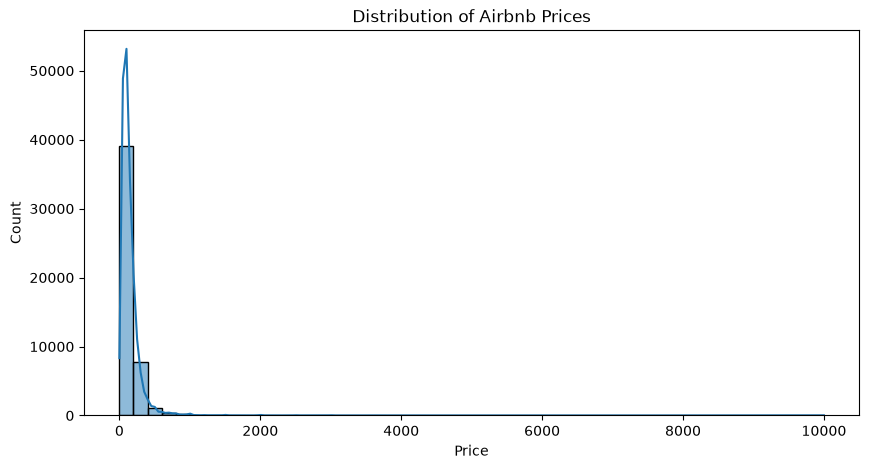

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(df_clean["price"], bins=50, kde=True)

plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

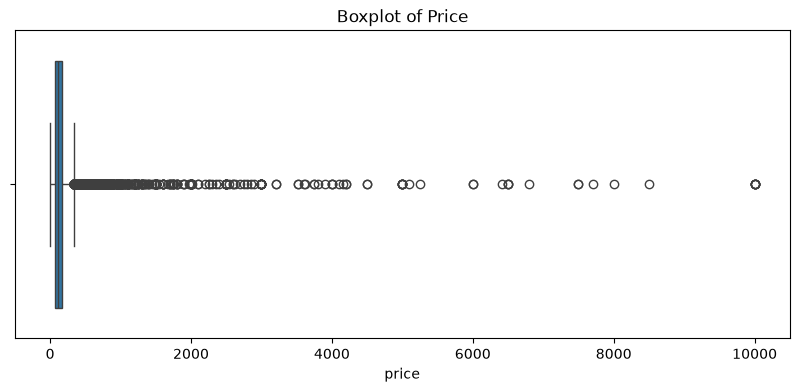

In [20]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df_clean["price"])

plt.title("Boxplot of Price")

plt.show()

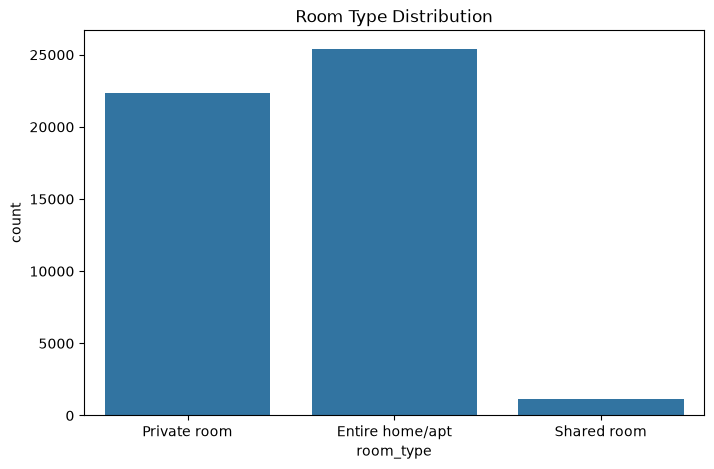

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_clean, x="room_type")

plt.title("Room Type Distribution")

plt.show()

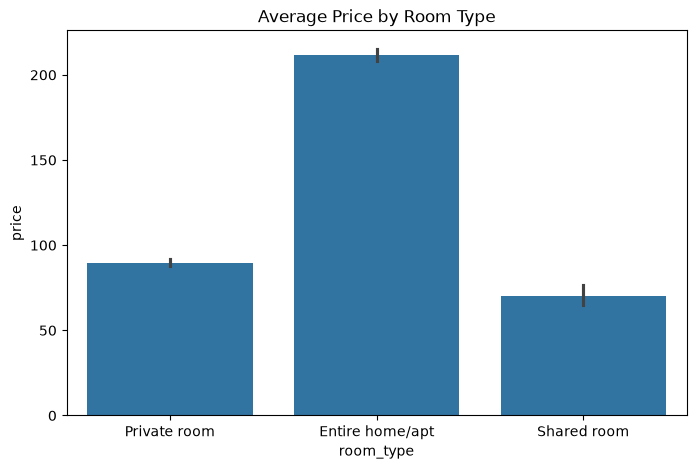

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df_clean,
    x="room_type",
    y="price",
    estimator="mean"
)

plt.title("Average Price by Room Type")

plt.show()

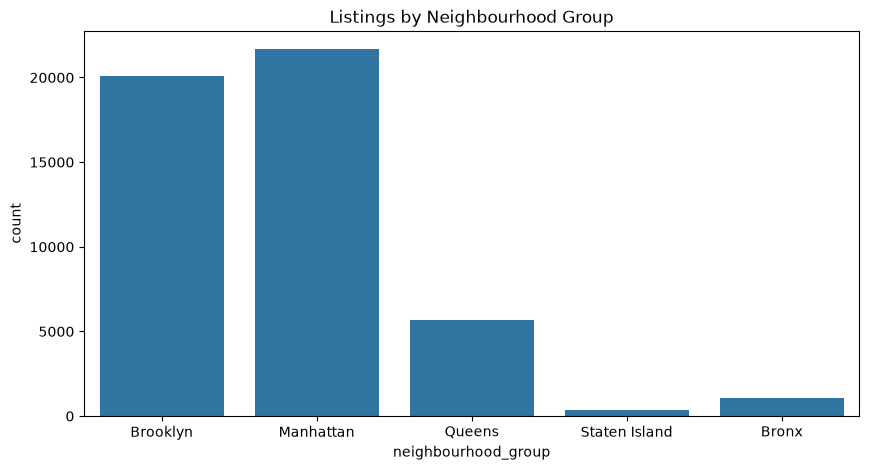

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_clean,
    x="neighbourhood_group"
)

plt.title("Listings by Neighbourhood Group")

plt.show()

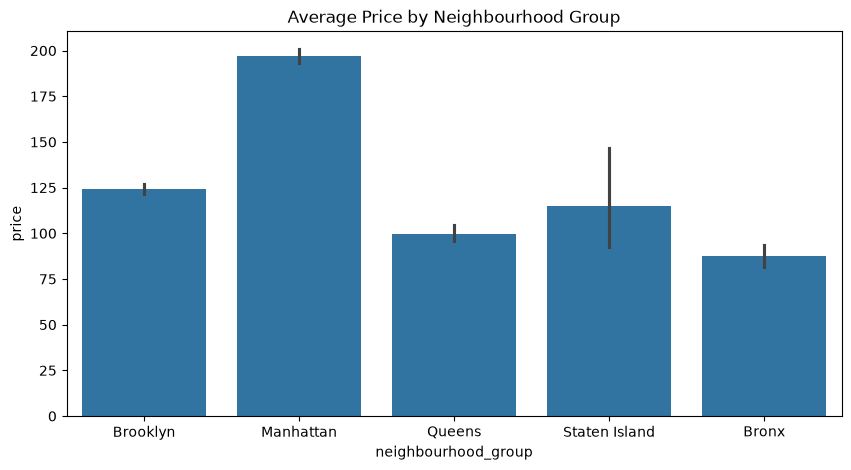

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df_clean,
    x="neighbourhood_group",
    y="price",
    estimator="mean"
)

plt.title("Average Price by Neighbourhood Group")

plt.show()

Correlation Heatmap

In [25]:
numeric_df = df_clean.select_dtypes(include=["int64", "float64"])

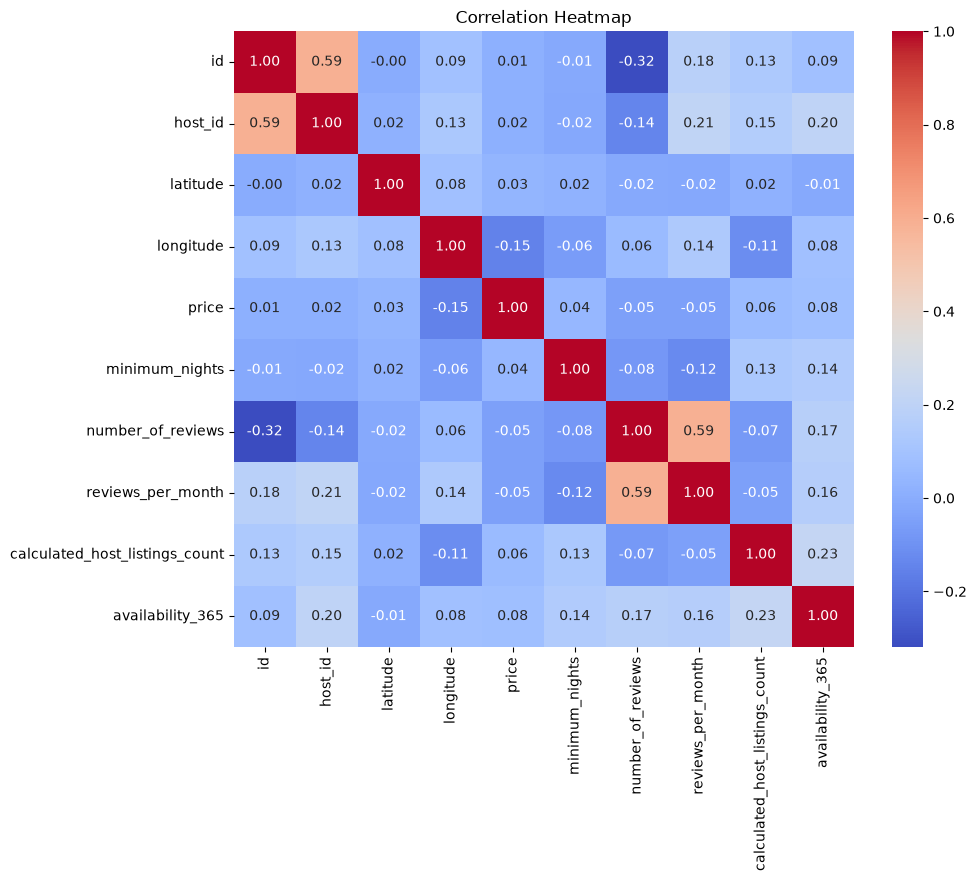

In [26]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Price vs Minimum Nights

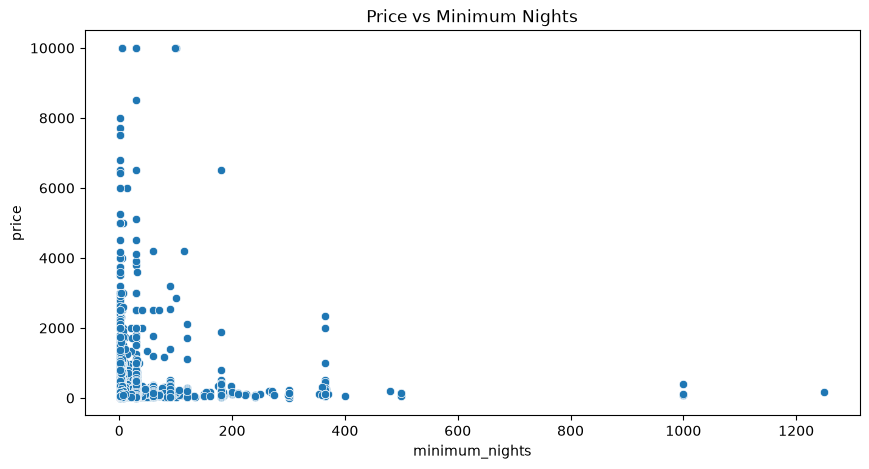

In [27]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_clean,
    x="minimum_nights",
    y="price"
)

plt.title("Price vs Minimum Nights")

plt.show()

Price vs Availability

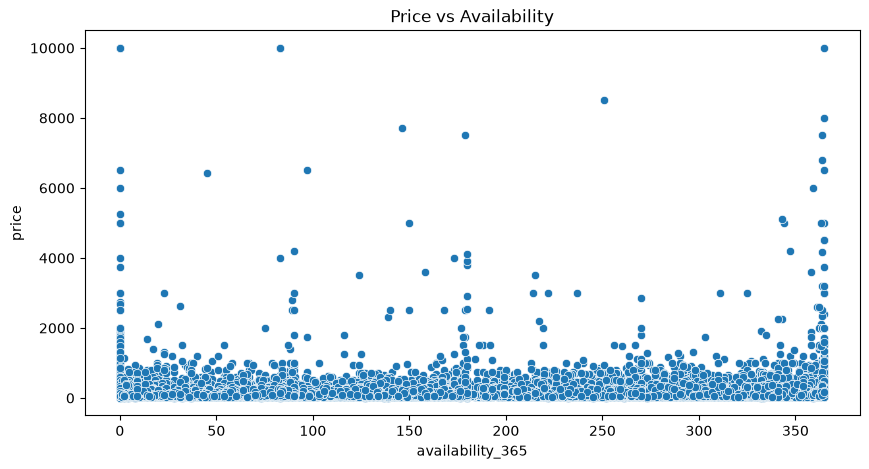

In [28]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_clean,
    x="availability_365",
    y="price"
)

plt.title("Price vs Availability")

plt.show()

Outlier Detection & Treatment

1. Calculate IQR

In [29]:
Q1 = df_clean["price"].quantile(0.25)
Q3 = df_clean["price"].quantile(0.75)

IQR = Q3 - Q1

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR:", IQR)

Q1 : 69.0
Q3 : 175.0
IQR: 106.0


Calculate Bounds

In [30]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

-90.0
334.0


Count Outliers

In [31]:
outliers = df_clean[
    (df_clean["price"] < lower_bound) |
    (df_clean["price"] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 2972


Percentage of Outliers

In [32]:
percentage = (len(outliers) / len(df_clean)) * 100

print(f"Outlier Percentage: {percentage:.2f}%")

Outlier Percentage: 6.08%


Create a New Dataset Without Outliers

In [33]:
df_no_outliers = df_clean[
    (df_clean["price"] >= lower_bound) &
    (df_clean["price"] <= upper_bound)
]

print(df_no_outliers.shape)

(45923, 16)


Compare Before and After

Before

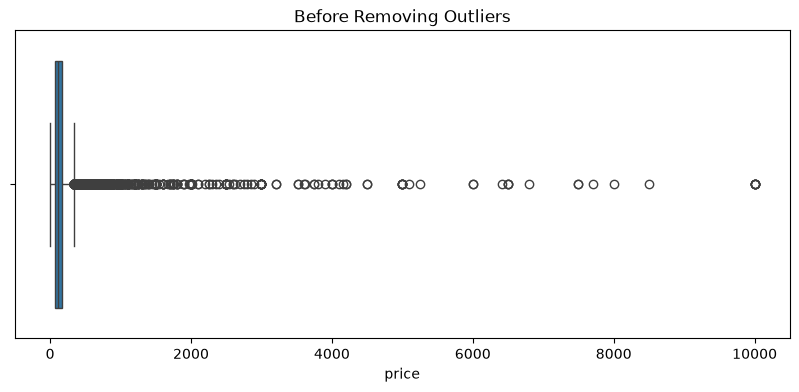

In [34]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df_clean["price"])
plt.title("Before Removing Outliers")
plt.show()

After

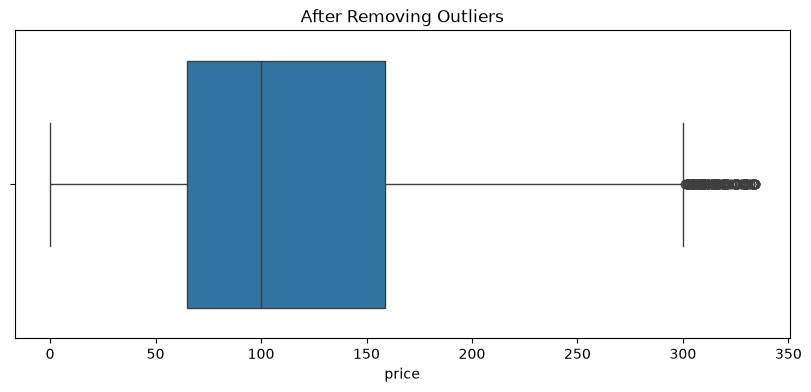

In [35]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df_no_outliers["price"])
plt.title("After Removing Outliers")
plt.show()

# ==========================================
# : Feature Engineering
# ==========================================

1. Convert last_review to useful features

In [36]:
df_clean["review_year"] = df_clean["last_review"].dt.year
df_clean["review_month"] = df_clean["last_review"].dt.month

2. Create a "has_review" feature

In [37]:
df_clean["has_review"] = df_clean["last_review"].notnull().astype(int)

3. Drop columns we won't use

In [38]:
df_clean = df_clean.drop(
    columns=[
        "id",
        "host_id",
        "name",
        "host_name",
        "last_review"
    ]
)

4. Check the final columns

In [39]:
df_clean.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'review_year', 'review_month', 'has_review'],
      dtype='str')

In [40]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  str    
 1   neighbourhood                   48895 non-null  str    
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  str    
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
 11  review_year                     38843 non-null  float64
 12  review_month                    38843 non-n

Data Preprocessing

1. Separate Features and Target

In [41]:
# Features
X = df_clean.drop("price", axis=1)

# Target
y = df_clean["price"]

In [42]:
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (48895, 13)
y Shape: (48895,)


2. Identify Numerical and Categorical Columns

In [43]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'review_year', 'review_month', 'has_review']

Categorical Features:
['neighbourhood_group', 'neighbourhood', 'room_type']


3. Create Numerical Pipeline

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

4. Create Categorical Pipeline

In [45]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

5. Combine Both Pipelines

In [46]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

6. Split the Dataset

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.20,random_state=42 )

In [48]:
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (39116, 13)
Testing Data  : (9779, 13)


7. Fit the Preprocessor

In [49]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [50]:
print("Processed Training Shape:", X_train_processed.shape)
print("Processed Testing Shape :", X_test_processed.shape)

Processed Training Shape: (39116, 238)
Processed Testing Shape : (9779, 238)



: Model Training

We'll compare two models:

1. Linear Regression (Baseline)
2. Random Forest Regressor

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

Linear Regression

In [52]:
lr_model = LinearRegression()

lr_model.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](238,)","[ -7.4 ,-34.29, -2.71,..., 78.1 ,-21.74,-56.35]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,97.86
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,238


In [53]:
lr_predictions = lr_model.predict(X_test_processed)

Evaluate Linear Regression

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print(f"MAE  : {lr_mae:.2f}")
print(f"RMSE : {lr_rmse:.2f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Performance
MAE  : 68.76
RMSE : 195.31
R²   : 0.1377


Train Random Forest

In [55]:
rf_model = RandomForestRegressor(n_estimators=200,random_state=42, n_jobs=-1)

rf_model.fit(X_train_processed, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [56]:
rf_predictions = rf_model.predict(X_test_processed)

In [57]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print(f"MAE  : {rf_mae:.2f}")
print(f"RMSE : {rf_rmse:.2f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Performance
MAE  : 63.22
RMSE : 199.38
R²   : 0.1014


Compare Models

In [58]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,68.759376,195.307651,0.137735
1,Random Forest,63.218065,199.381267,0.101391


Save the Model

In [59]:
import joblib

joblib.dump(rf_model, "airbnb_price_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


Test the Saved Model

In [60]:
loaded_model = joblib.load("airbnb_price_model.pkl")
loaded_preprocessor = joblib.load("preprocessor.pkl")

In [61]:
sample = X.iloc[[0]]

sample_processed = loaded_preprocessor.transform(sample)

prediction = loaded_model.predict(sample_processed)

print("Predicted Price:", prediction[0])
print("Actual Price:", y.iloc[0])

Predicted Price: 132.87
Actual Price: 149
